# 1.Load Dataset

In [1]:
import pandas as pd

# Load your clean dataset (update file name if needed)
df = pd.read_csv("/content/DM1_game_dataset_module.01.csv")

df.head()


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,1.609438,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,1.791759,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,1.791759,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,1.098612,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,1.609438,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


# 2.checking missing values

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21925 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  float64
 8   ComAgeRec            21925 non-null  float64
 9   LanguageEase         21925 non-null  float64
 10  GoodPlayers          21925 non-null  object 
 11  NumOwned             21925 non-null  int64  
 12  NumWant              21925 non-null  int64  
 13  NumWish              21925 non-null  int64  
 14  NumWeightVotes       21925 non-null  float64
 15  ComMinPlaytime       21925 non-null 

# 3.check target varible distribution

Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64


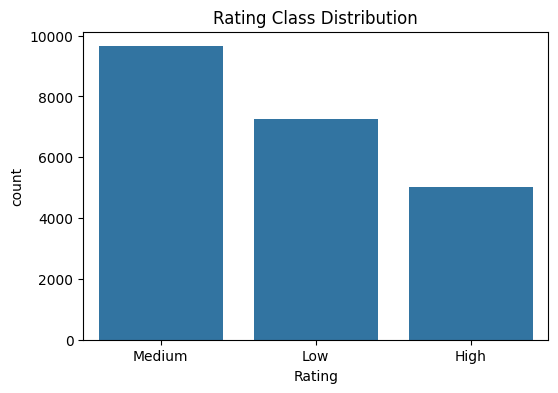

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df['Rating'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df['Rating'], order=df['Rating'].value_counts().index)
plt.title("Rating Class Distribution")
plt.show()


In [4]:
df_corr = df.copy()
df_corr['Rating_encoded'] = df_corr['Rating'].map({'Low':0, 'Medium':1, 'High':2})


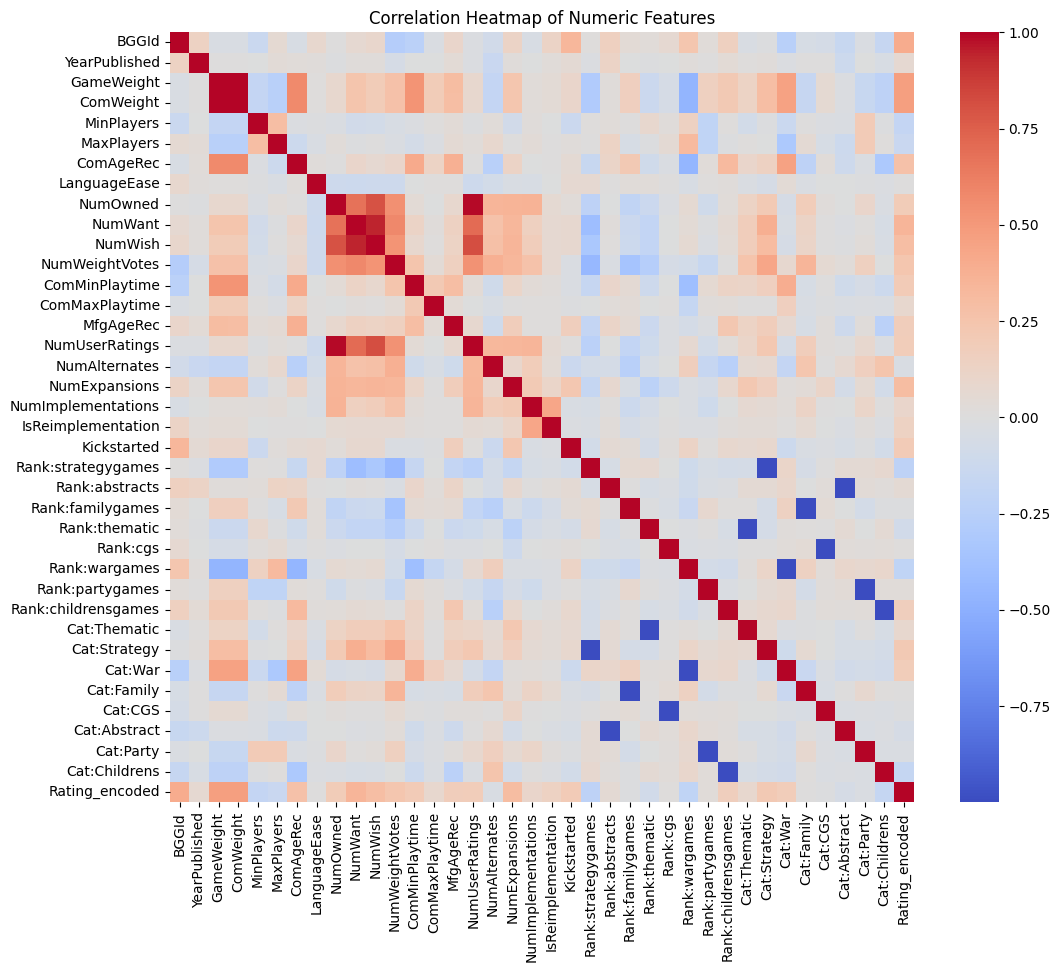

In [5]:
corr = df_corr.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [6]:
corr_with_rating = corr['Rating_encoded'].sort_values(ascending=False)
corr_with_rating


,Rating_encoded
Rating_encoded,1.000000
GameWeight,0.474870
ComWeight,0.473836
BGGId,0.399595
NumWant,0.344737
NumExpansions,0.301794
NumWish,0.293406
ComAgeRec,0.269389
NumWeightVotes,0.236144
Cat:Strategy,0.211504


**5.Baseline decision tree**

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Numeric features
X = df.select_dtypes(include=['int64', 'float64'])

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Rating'])

# Train-test split (stratify to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Baseline Decision Tree (default parameters)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

# Predictions
y_pred_base = dt_base.predict(X_test)

# Metrics
print("=== BASELINE RESULTS ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_base, average='macro'):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_base, average='macro'):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_base, average='macro'):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))


=== BASELINE RESULTS ===
Accuracy : 0.671
Precision: 0.676
Recall   : 0.672
F1-score : 0.674

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.66      0.67      1007
         Low       0.70      0.70      0.70      1449
      Medium       0.65      0.66      0.65      1929

    accuracy                           0.67      4385
   macro avg       0.68      0.67      0.67      4385
weighted avg       0.67      0.67      0.67      4385



**6.confusion matrix**

<Figure size 600x500 with 0 Axes>

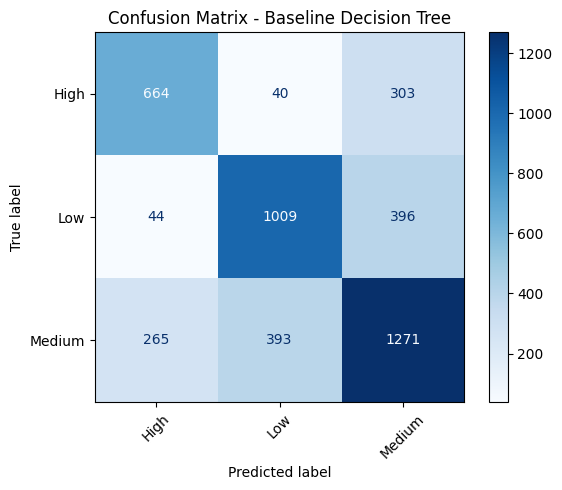

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.show()


**Roc Curve for baseline**

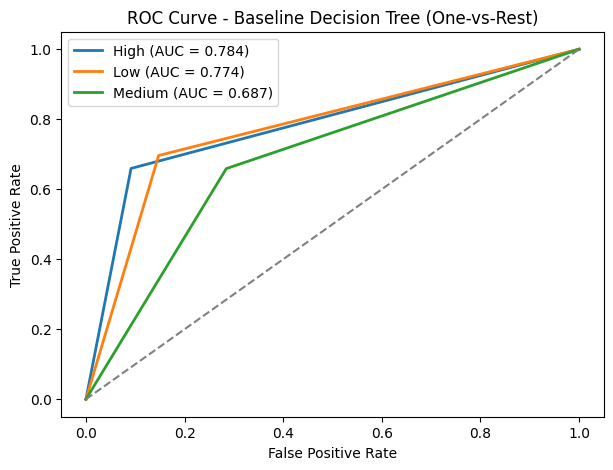

In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize target classes (Low=0, Medium=1, High=2)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# Predict probabilities for baseline model
y_score_base = dt_base.predict_proba(X_test)

plt.figure(figsize=(7,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_base[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Decision Tree (One-vs-Rest)')
plt.legend()
plt.show()


**7.feautre importance**

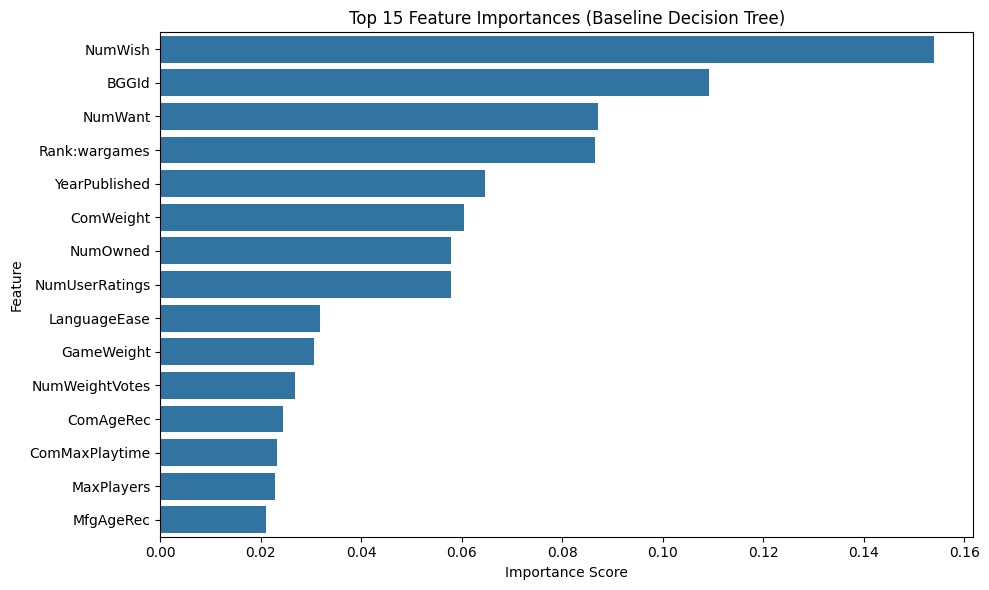

In [10]:
import numpy as np

importances = dt_base.feature_importances_
feature_names = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:15],
            y=feature_names[indices][:15])
plt.title("Top 15 Feature Importances (Baseline Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Hyperparameter Tuning (GridSearchCV)

To improve the performance of the baseline Decision Tree, we performed hyperparameter tuning using GridSearchCV. This technique automatically evaluates multiple parameter combinations using Stratified K-Fold Cross-Validation, ensuring a fair and robust selection of the best model configuration.

We optimized the following parameters:

criterion: measure of impurity (gini, entropy)

max_depth: maximum depth of the tree

min_samples_split: minimum samples needed to split a node

min_samples_leaf: minimum samples required in a leaf node

GridSearchCV trains the model on different parameter combinations and selects the configuration that achieves the highest average validation accuracy. This process prevents overfitting and helps the model generalize better to new, unseen data

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

dt = DecisionTreeClassifier(random_state=42, class_weight=None)

grid_search = GridSearchCV(dt,
                           param_grid,
                           cv=skf,
                           scoring='accuracy',
                           n_jobs=-1,
                           return_train_score=True)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)



Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Accuracy: 0.7034776819151799


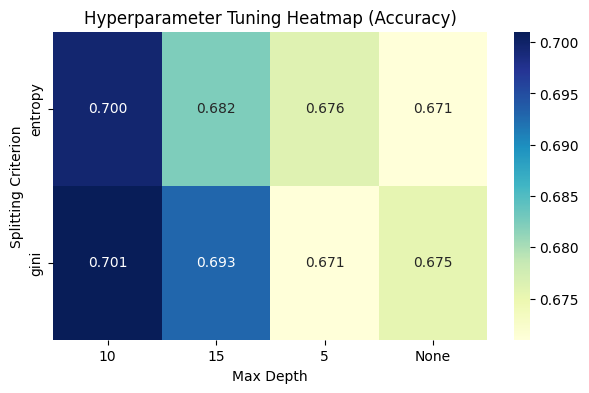

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract grid results
results = pd.DataFrame(grid_search.cv_results_)

# Select only relevant columns
results_simple = results[['mean_test_score', 'param_criterion', 'param_max_depth']]

# Convert parameter values to strings (for labeling)
results_simple.loc[:, 'param_criterion'] = results_simple['param_criterion'].astype(str)
results_simple.loc[:, 'param_max_depth'] = results_simple['param_max_depth'].astype(str)

# Group by criterion + depth to avoid duplicate errors
grouped = results_simple.groupby(['param_criterion', 'param_max_depth']).mean().reset_index()

# Pivot for heatmap
heatmap_data = grouped.pivot(index='param_criterion',
                             columns='param_max_depth',
                             values='mean_test_score')

plt.figure(figsize=(7,4))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Hyperparameter Tuning Heatmap (Accuracy)")
plt.xlabel("Max Depth")
plt.ylabel("Splitting Criterion")
plt.show()


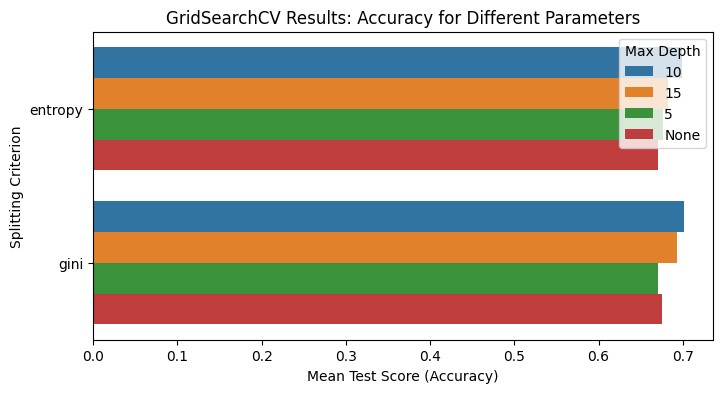

In [13]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=grouped,
    x='mean_test_score',
    y='param_criterion',
    hue='param_max_depth'
)
plt.title("GridSearchCV Results: Accuracy for Different Parameters")
plt.xlabel("Mean Test Score (Accuracy)")
plt.ylabel("Splitting Criterion")
plt.legend(title="Max Depth")
plt.show()


# Results of tuned dataset



confusion matrix

In [14]:
# Train Decision Tree with best parameters
dt_best = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
dt_best.fit(X_train, y_train)

# Predictions
y_pred_best = dt_best.predict(X_test)

# Metrics
print("=== TUNED MODEL RESULTS ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_best, average='macro'):.3f}")


=== TUNED MODEL RESULTS ===
Accuracy : 0.709
Precision: 0.726
Recall   : 0.697
F1-score : 0.708


<Figure size 600x500 with 0 Axes>

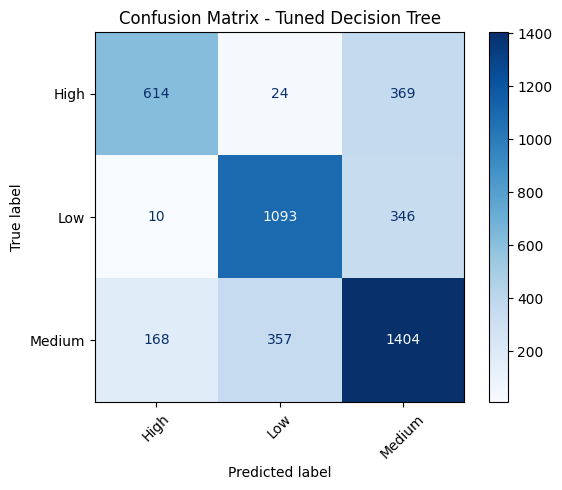

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                              display_labels=le.classes_)
plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()


Feautre importance

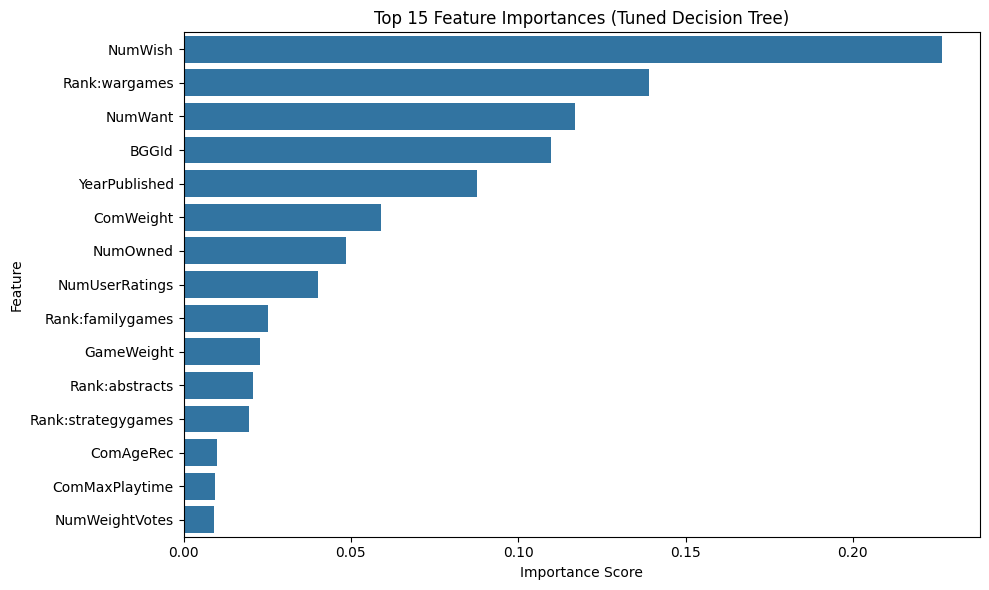

In [16]:
importances_best = dt_best.feature_importances_
indices_best = np.argsort(importances_best)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances_best[indices_best][:15],
            y=X.columns[indices_best][:15])
plt.title("Top 15 Feature Importances (Tuned Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Roc curve

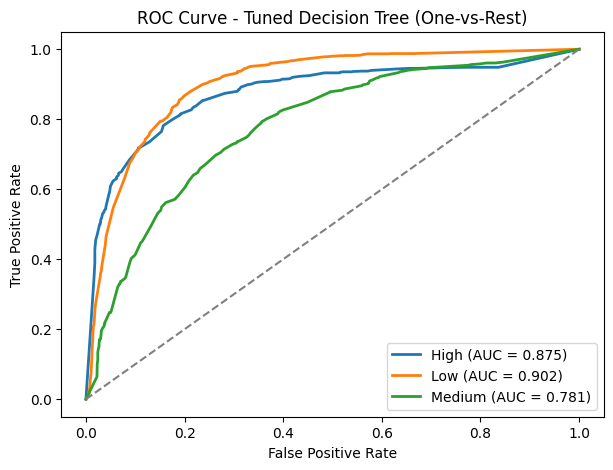

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize target classes
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

# Predict probabilities
y_score = dt_best.predict_proba(X_test)

plt.figure(figsize=(7,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{le.classes_[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree (One-vs-Rest)')
plt.legend()
plt.show()


The ROC curve provides a visual assessment of the model’s ability to separate each rating class. The AUC scores confirm that the model performs very well in classifying Low-rated games (AUC = 0.902) and High-rated games (AUC = 0.875), indicating strong discriminative power.

However, the Medium class shows the lowest AUC (0.781), reflecting greater overlap in feature characteristics between Medium and the other rating categories. This confirms previous observations from the confusion matrix, where Medium games were the most frequently misclassified.

# Decision Tree Visualization

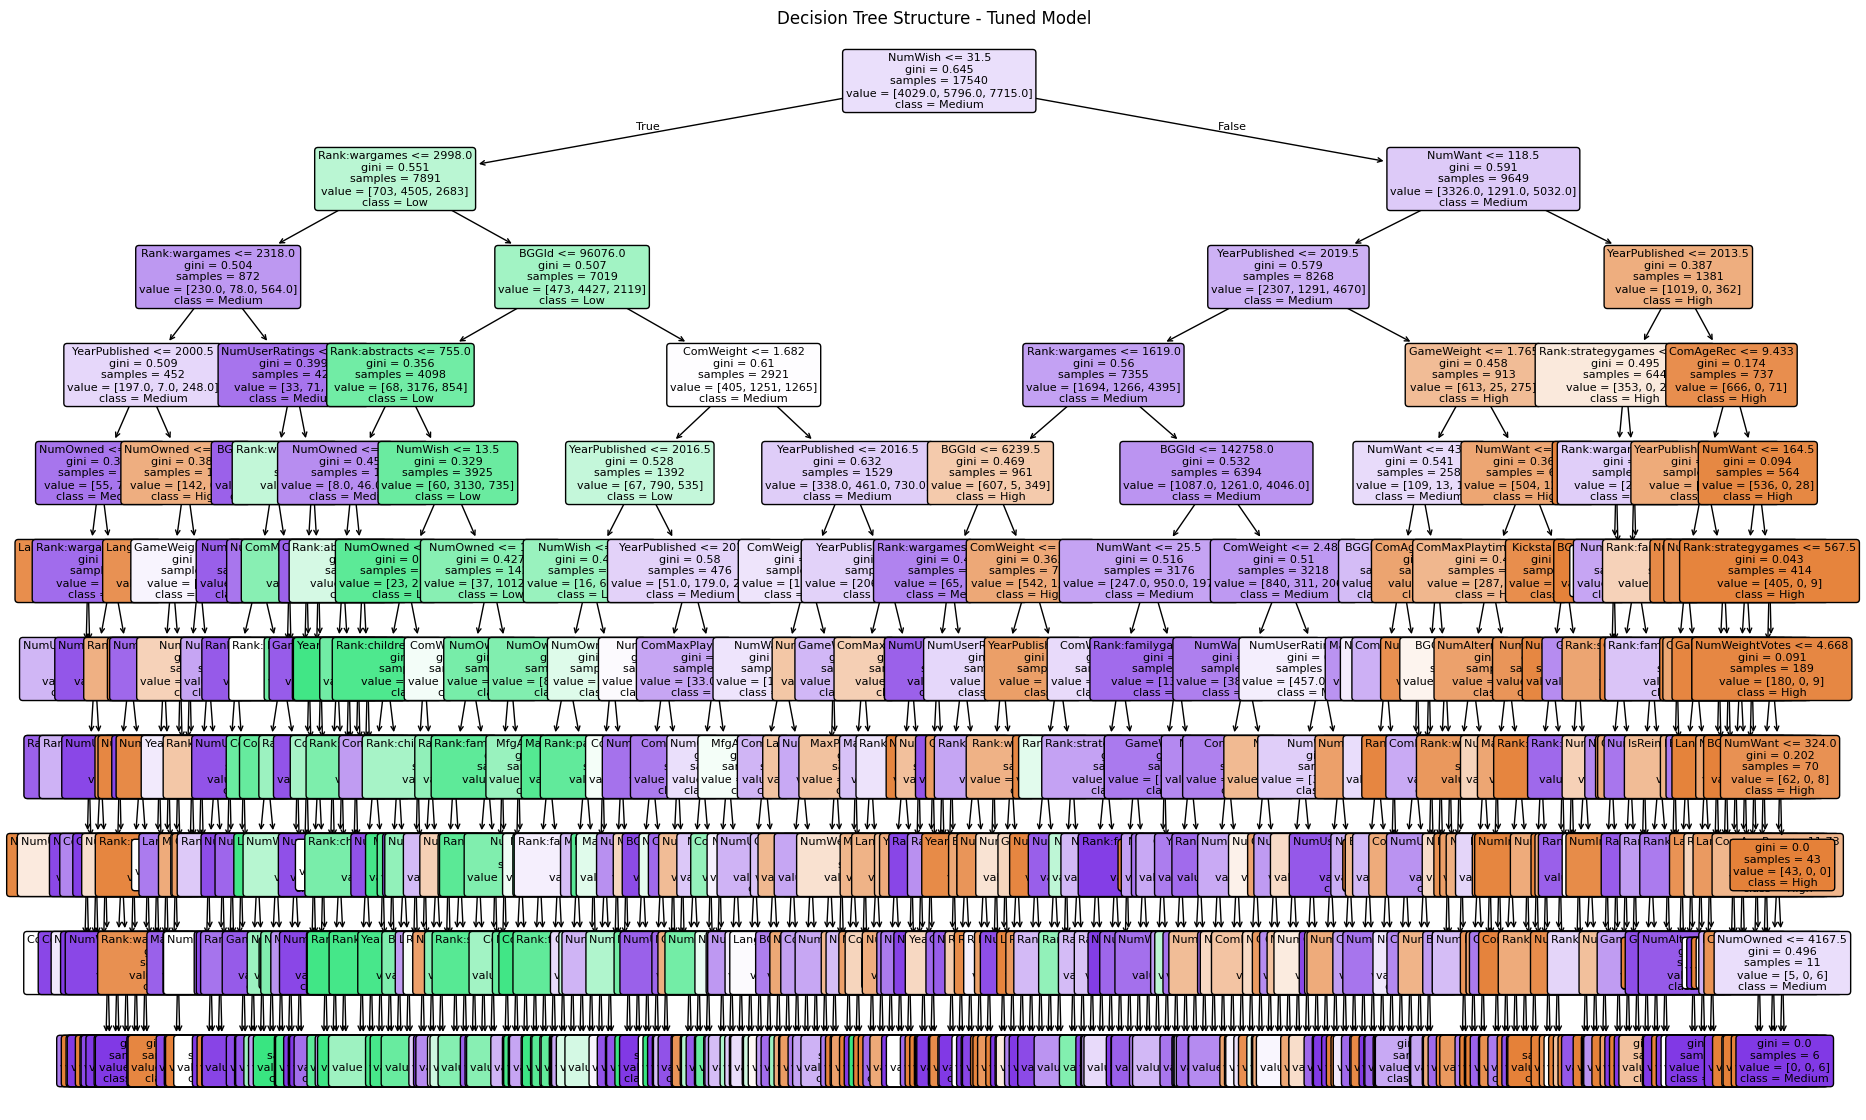

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 14))
plot_tree(dt_best,
          feature_names=X.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Structure - Tuned Model")
plt.show()


To reduce depth of decision tree



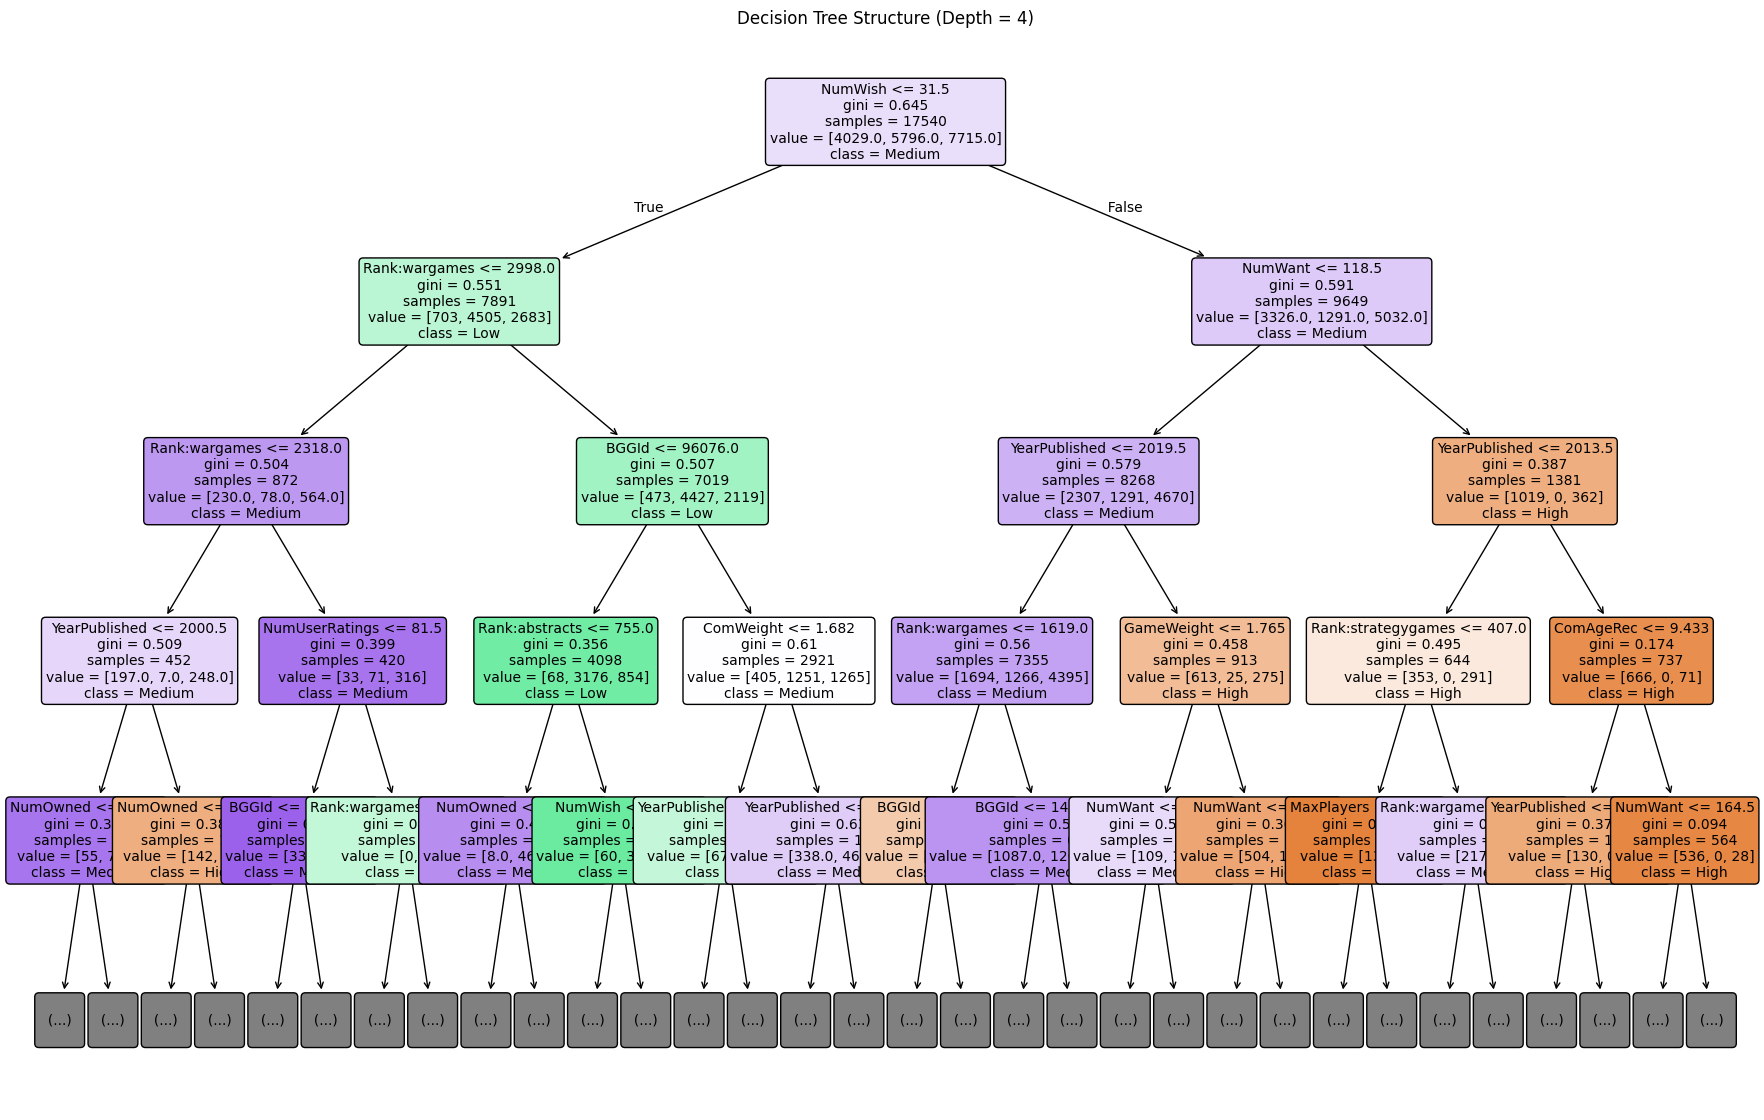

In [19]:
plt.figure(figsize=(22, 14))
plot_tree(dt_best,
          feature_names=X.columns,
          class_names=le.classes_,
          max_depth=4,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Structure (Depth = 4)")
plt.show()


In [20]:
from sklearn.tree import export_text

tree_rules = export_text(dt_best,
                         feature_names=list(X.columns),
                         show_weights=True)
print(tree_rules)


|--- NumWish <= 31.50
|   |--- Rank:wargames <= 2998.00
|   |   |--- Rank:wargames <= 2318.00
|   |   |   |--- YearPublished <= 2000.50
|   |   |   |   |--- NumOwned <= 113.00
|   |   |   |   |   |--- LanguageEase <= 330.50
|   |   |   |   |   |   |--- weights: [9.00, 0.00, 0.00] class: 0
|   |   |   |   |   |--- LanguageEase >  330.50
|   |   |   |   |   |   |--- weights: [1.00, 0.00, 1.00] class: 0
|   |   |   |   |--- NumOwned >  113.00
|   |   |   |   |   |--- Rank:wargames <= 1539.50
|   |   |   |   |   |   |--- NumUserRatings <= 99.00
|   |   |   |   |   |   |   |--- NumOwned <= 370.50
|   |   |   |   |   |   |   |   |--- NumWeightVotes <= 2.99
|   |   |   |   |   |   |   |   |   |--- weights: [18.00, 0.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- NumWeightVotes >  2.99
|   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00, 1.00] class: 0
|   |   |   |   |   |   |   |--- NumOwned >  370.50
|   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00, 1.00] class: 

In [21]:
from sklearn.tree import export_text

tree_rules = export_text(dt_best, feature_names=list(X.columns))
print(tree_rules[:1500])  # show first ~1500 characters


|--- NumWish <= 31.50
|   |--- Rank:wargames <= 2998.00
|   |   |--- Rank:wargames <= 2318.00
|   |   |   |--- YearPublished <= 2000.50
|   |   |   |   |--- NumOwned <= 113.00
|   |   |   |   |   |--- LanguageEase <= 330.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- LanguageEase >  330.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- NumOwned >  113.00
|   |   |   |   |   |--- Rank:wargames <= 1539.50
|   |   |   |   |   |   |--- NumUserRatings <= 99.00
|   |   |   |   |   |   |   |--- NumOwned <= 370.50
|   |   |   |   |   |   |   |   |--- NumWeightVotes <= 2.99
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- NumWeightVotes >  2.99
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- NumOwned >  370.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- NumUserRatings >  99.00
|   |   |   |   |   |   |   |--- Rank:wargames <= 957.50
|   |   |   |   |   |   |   |

[Text(0.5, 0.9166666666666666, 'NumWish <= 31.5\ngini = 0.645\nsamples = 17540\nvalue = [4029.0, 5796.0, 7715.0]\nclass = Medium'),
 Text(0.25, 0.75, 'Rank:wargames <= 2998.0\ngini = 0.551\nsamples = 7891\nvalue = [703, 4505, 2683]\nclass = Low'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'Rank:wargames <= 2318.0\ngini = 0.504\nsamples = 872\nvalue = [230.0, 78.0, 564.0]\nclass = Medium'),
 Text(0.0625, 0.4166666666666667, 'YearPublished <= 2000.5\ngini = 0.509\nsamples = 452\nvalue = [197.0, 7.0, 248.0]\nclass = Medium'),
 Text(0.03125, 0.25, 'NumOwned <= 113.0\ngini = 0.376\nsamples = 259\nvalue = [55, 7, 197]\nclass = Medium'),
 Text(0.015625, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.046875, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.09375, 0.25, 'NumOwned <= 217.5\ngini = 0.389\nsamples = 193\nvalue = [142, 0, 51]\nclass = High'),
 Text(0.078125, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.109375, 0.08333333333333333, '\n  (...)  \n')

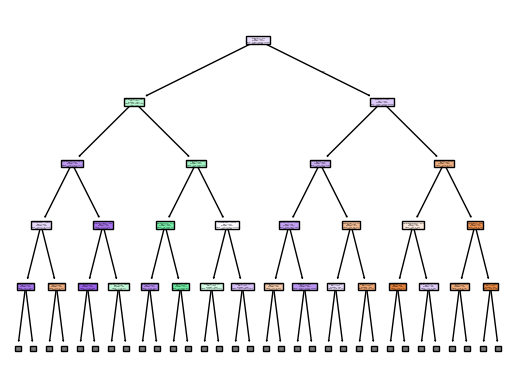

In [22]:
# Remove technical identifier for interpretability
X_vis = X_train.drop(columns=['BGGId'])

# Train a copy of the tuned tree for visualization only
dt_vis = DecisionTreeClassifier(**grid_search.best_params_, random_state=42).fit(X_vis, y_train)

# Plot truncated tree
plot_tree(dt_vis, feature_names=X_vis.columns, class_names=le.classes_, max_depth=4, filled=True)


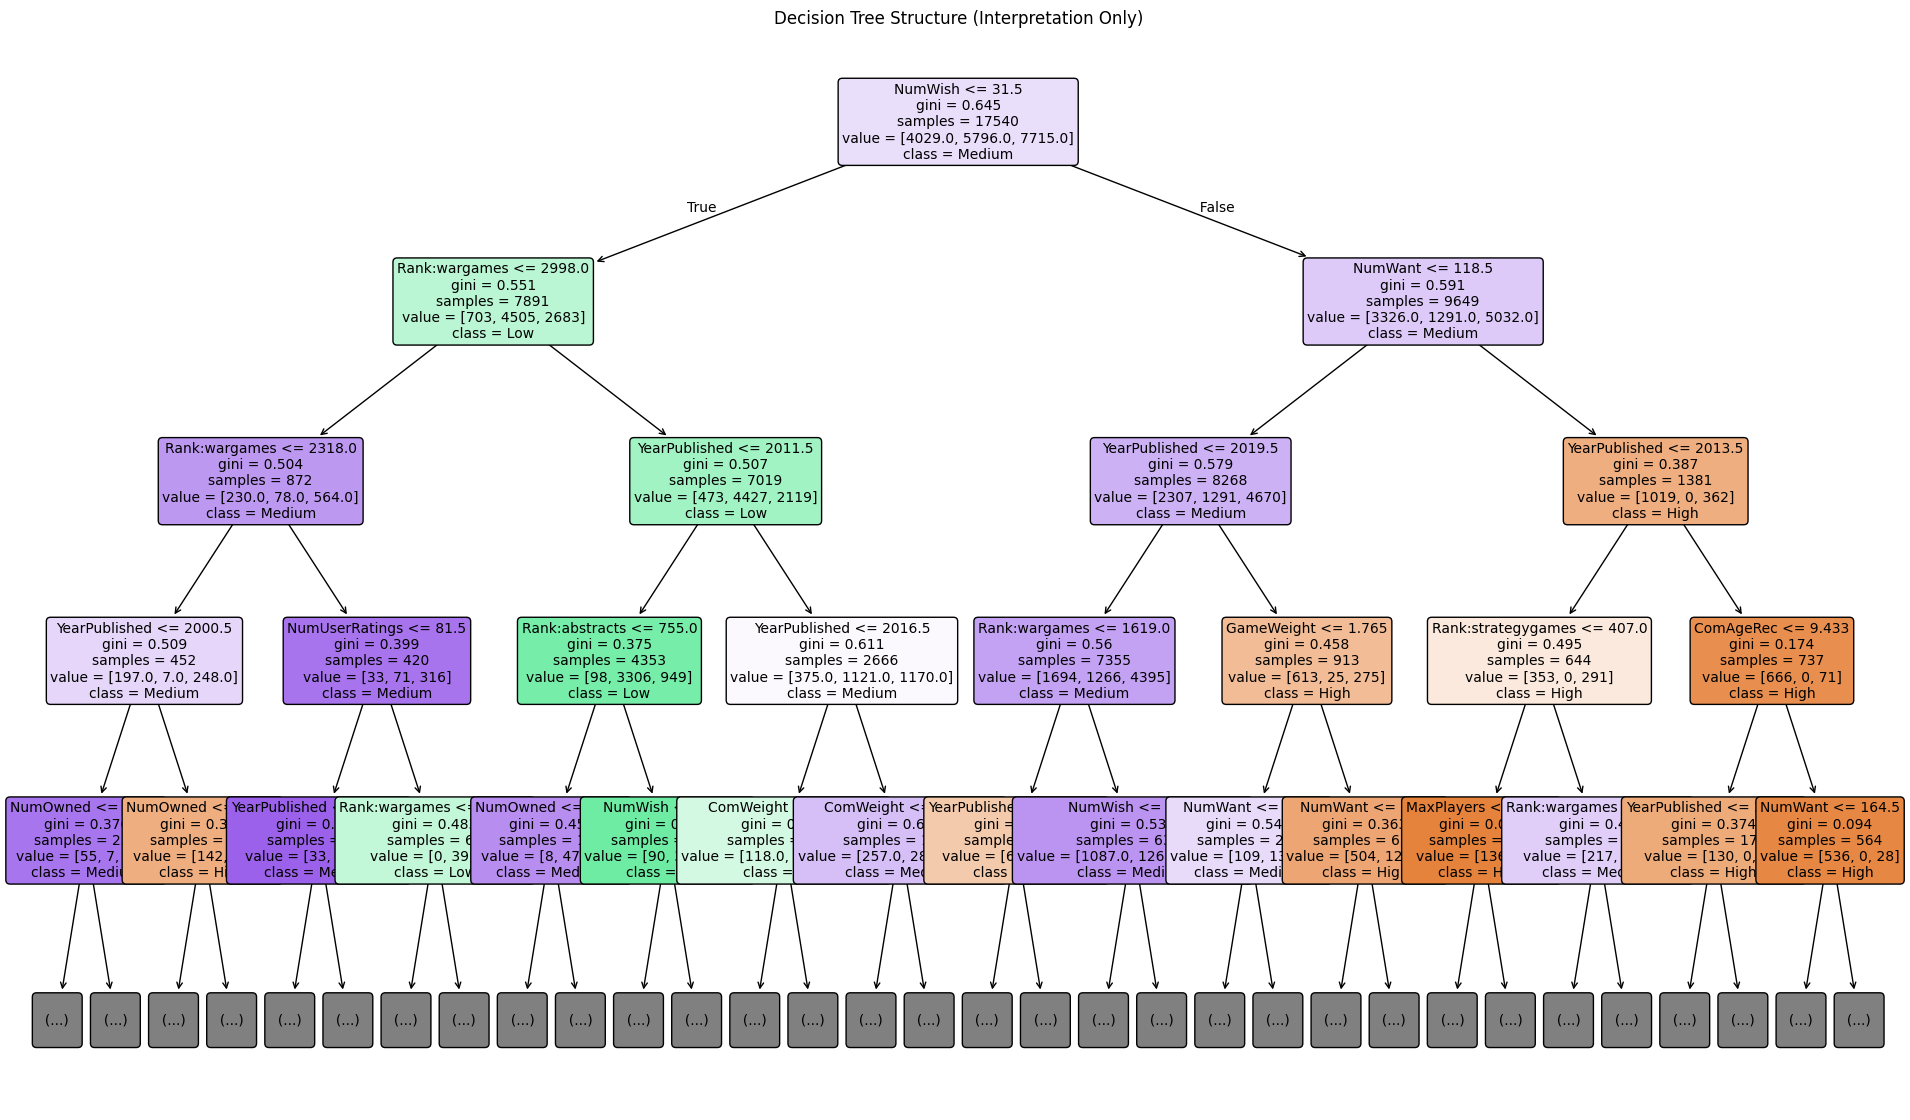

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 14))   # IMPORTANT
plot_tree(
    dt_vis,
    feature_names=X_vis.columns,
    class_names=le.classes_,
    max_depth=4,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure (Interpretation Only)")
plt.show()
